<a href="https://colab.research.google.com/github/manidharc7/ISI-2026-Group1-Property-Valuation/blob/main/Group1_Property_Valuation_Colab(final).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏡 AI Property Valuation Assistant — ISI Group 1
### Complete, ready-to-run notebook · Modules **M0 → M9** + the **web app**

**How to run:** in the menu click **Runtime → Run all**. It takes ~1–2 minutes. When it
finishes, the **last cell prints a public link ending in `.gradio.live`** — open it, or
share it, to use the live web app.

**What it does:** loads Dean De Cock's **Ames housing** data (2,930 real house sales),
compares **two** models — **Linear Regression** (baseline) vs **Random Forest** — to predict
`SalePrice`, picks the winner, then a free **Groq LLM** writes a plain-English valuation for
each house. **The model predicts the price; the LLM only explains it — it never invents the number.**

**AI write-up key (optional):** the explanations use a free **Groq** key. No key? The app
still runs and shows a short offline summary for each house — see **M9** for the 30-second
Colab Secrets setup if you want live AI write-ups.

## M0 · Setup

In [1]:
# Install the two libraries Colab doesn't ship with (a few seconds).
!pip install -q gradio groq

# Colab already has pandas, numpy, scikit-learn and matplotlib.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
print("setup ok")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 3.6 MB/s eta 0:00:00
setup ok


## M1 · Load the data
The Ames housing file is **fetched automatically** from the project's public GitHub repo
(Dean De Cock's original **2,930 house sales × 82 columns**) — nothing to upload.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/devdutta/isi-2026-property-valuation/main/AmesHousing.csv"
df = pd.read_csv(DATA_URL)
print("loaded:", df.shape, "(rows, columns)")
df[["Overall Qual", "Gr Liv Area", "Year Built", "Neighborhood", "SalePrice"]].head()

loaded: (2930, 82) (rows, columns)


,Overall Qual,Gr Liv Area,Year Built,Neighborhood,SalePrice
0,6,1656,1960,NAmes,215000
1,5,896,1961,NAmes,105000
2,6,1329,1958,NAmes,172000
3,7,2110,1968,NAmes,244000
4,5,1629,1997,Gilbert,189900


## M2 · Clean & select the feature subset
De Cock's own guidance: drop the **5 abnormal large-area sales** (`Gr Liv Area` > 4000).
We predict `SalePrice` from **14 features** — 13 numeric + the `Neighborhood`.

In [3]:
NUMERIC = ["Overall Qual", "Gr Liv Area", "Total Bsmt SF", "Garage Cars", "Garage Area",
           "Year Built", "Year Remod/Add", "Full Bath", "TotRms AbvGrd", "1st Flr SF",
           "Lot Area", "Fireplaces", "Bedroom AbvGr"]
CATEGORICAL = ["Neighborhood"]
TARGET = "SalePrice"
FEATURES = NUMERIC + CATEGORICAL

before = len(df)
df = df[df["Gr Liv Area"] <= 4000].copy()
print(f"dropped {before - len(df)} outliers; rows now {len(df)}")

X = df[FEATURES].copy()
y = df[TARGET].copy()
print(f"X={X.shape}  y={y.shape}  ({len(NUMERIC)} numeric + {len(CATEGORICAL)} categorical)")

dropped 5 outliers; rows now 2925
X=(2925, 14)  y=(2925,)  (13 numeric + 1 categorical)


## M3 · EDA — what drives price?
Two quick pictures: how sale prices are distributed, and which features move most with price.

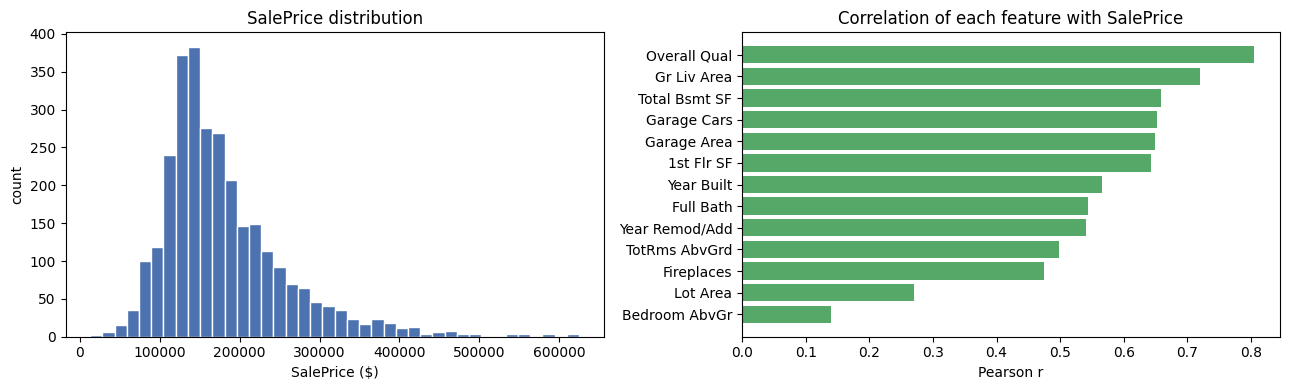

top correlations with SalePrice:
  Overall Qual       r=+0.805
  Gr Liv Area        r=+0.719
  Total Bsmt SF      r=+0.659
  Garage Cars        r=+0.653
  Garage Area        r=+0.648


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(y, bins=40, color="#4C72B0", edgecolor="white")
ax[0].set_title("SalePrice distribution"); ax[0].set_xlabel("SalePrice ($)"); ax[0].set_ylabel("count")

corr = df[NUMERIC + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()
ax[1].barh(corr.index, corr.values, color="#55A868")
ax[1].set_title("Correlation of each feature with SalePrice"); ax[1].set_xlabel("Pearson r")
plt.tight_layout(); plt.show()

print("top correlations with SalePrice:")
for name, r in corr.sort_values(ascending=False).head(5).items():
    print(f"  {name:<18} r={r:+.3f}")

## M4 · Preprocess + split
80/20 train-test split (seed 42). Numeric features are median-imputed + scaled; `Neighborhood`
is most-frequent-imputed + one-hot encoded. One `ColumnTransformer` handles both together.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"train={len(X_train)}  test={len(X_test)}")

numeric_pipe = Pipeline([("impute", SimpleImputer(strategy="median")),
                         ("scale", StandardScaler())])
categorical_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                             ("onehot", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer([("num", numeric_pipe, NUMERIC),
                                  ("cat", categorical_pipe, CATEGORICAL)])
print("preprocessor ready")

train=2340  test=585
preprocessor ready


## M5 · Model A — Linear Regression (baseline)

In [6]:
lr = Pipeline([("prep", preprocessor), ("model", LinearRegression())])
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_metrics = {"rmse": float(np.sqrt(mean_squared_error(y_test, lr_pred))),
              "mae": float(mean_absolute_error(y_test, lr_pred)),
              "r2": float(r2_score(y_test, lr_pred))}
print(f"Linear Regression  RMSE=${lr_metrics['rmse']:,.0f}  MAE=${lr_metrics['mae']:,.0f}  R2={lr_metrics['r2']:.3f}")

Linear Regression  RMSE=$29,581  MAE=$19,153  R2=0.877


## M6 · Model B — Random Forest
Same preprocessing, a stronger model (300 trees). Watch the R² jump.

In [7]:
rf = Pipeline([("prep", preprocessor),
               ("model", RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))])
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_metrics = {"rmse": float(np.sqrt(mean_squared_error(y_test, rf_pred))),
              "mae": float(mean_absolute_error(y_test, rf_pred)),
              "r2": float(r2_score(y_test, rf_pred))}
print(f"Random Forest      RMSE=${rf_metrics['rmse']:,.0f}  MAE=${rf_metrics['mae']:,.0f}  R2={rf_metrics['r2']:.3f}")

Random Forest      RMSE=$24,011  MAE=$15,547  R2=0.919


## M7 · Compare, pick the winner, see what matters
The model with the higher R² becomes `final_model` — the one the app and the LLM use.

winner by R2: Random Forest   ->   final_model = Random Forest
            model       R2         RMSE
Linear Regression 0.876924 29581.265667
    Random Forest 0.918911 24010.957147


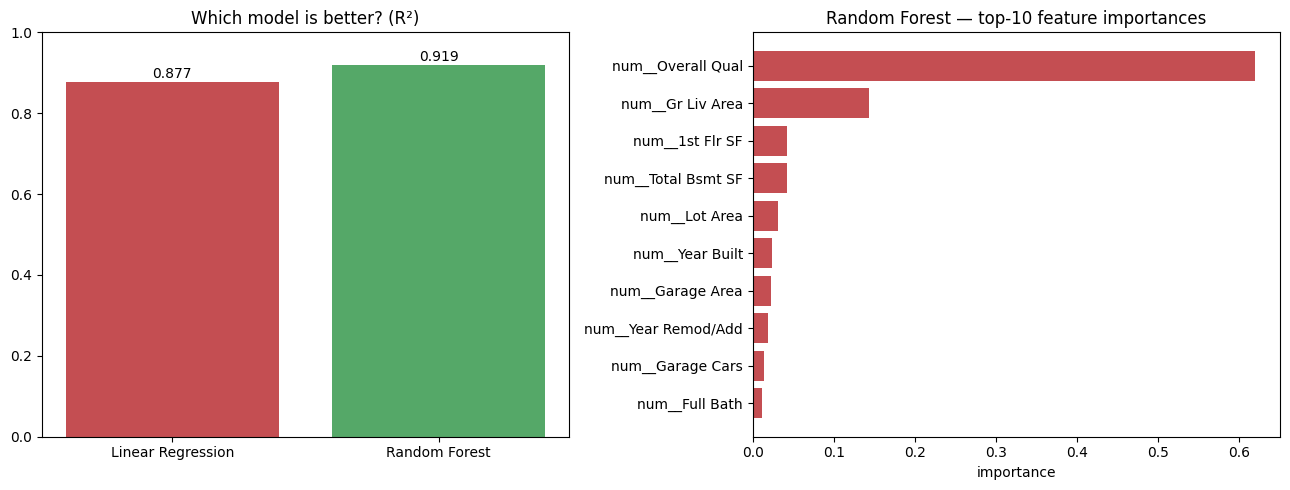

top drivers: ['Overall Qual', 'Gr Liv Area', '1st Flr SF', 'Total Bsmt SF']


In [8]:
winner = "Random Forest" if rf_metrics["r2"] > lr_metrics["r2"] else "Linear Regression"
final_model = rf if winner == "Random Forest" else lr
print(f"winner by R2: {winner}   ->   final_model = {winner}")

eval_table = pd.DataFrame({"model": ["Linear Regression", "Random Forest"],
                           "R2": [lr_metrics["r2"], rf_metrics["r2"]],
                           "RMSE": [lr_metrics["rmse"], rf_metrics["rmse"]]})
print(eval_table.to_string(index=False))

# feature importances from the Random Forest
feat_names = rf.named_steps["prep"].get_feature_names_out()
importances = rf.named_steps["model"].feature_importances_
top = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].bar(eval_table["model"], eval_table["R2"], color=["#C44E52", "#55A868"])
ax[0].set_title("Which model is better? (R²)"); ax[0].set_ylim(0, 1.0)
for i, v in enumerate(eval_table["R2"]):
    ax[0].text(i, v + 0.01, f"{v:.3f}", ha="center")
ax[1].barh(top.index[::-1], top.values[::-1], color="#C44E52")
ax[1].set_title("Random Forest — top-10 feature importances"); ax[1].set_xlabel("importance")
plt.tight_layout(); plt.show()

# the 4 biggest drivers, cleaned of the pipeline prefixes — the LLM references these
DRIVERS = [n.replace("num__", "").replace("cat__", "") for n in top.index[:4]]
print("top drivers:", DRIVERS)

## M8 · Use the model — price houses it has never seen
The payoff. We build 5 **held-out** sample houses (real houses the model never trained on,
spanning cheap → upper-mid) so the app shows accurate predicted-vs-actual out of the box.

In [9]:
# --- 5 held-out sample houses spanning the price range (real, unseen) ----------
_pred_test = pd.Series(final_model.predict(X_test), index=X_test.index)
_err = (_pred_test - y_test).abs() / y_test
_lo, _hi = y_test.quantile(0.05), y_test.quantile(0.88)
_edges = [_lo + (_hi - _lo) * i / 5 for i in range(6)]
_chosen = []
for b in range(5):
    _band = y_test[(y_test >= _edges[b]) & (y_test < _edges[b + 1])].index
    _cand = [i for i in _band if _err[i] <= 0.12 and i not in _chosen] or [i for i in _band if i not in _chosen]
    if _cand:
        _centre = (_edges[b] + _edges[b + 1]) / 2
        _chosen.append(min(_cand, key=lambda i: abs(y_test[i] - _centre)))
sample_df = X_test.loc[_chosen, FEATURES].copy()
sample_df[TARGET] = y_test.loc[_chosen].astype(int).values
sample_df = sample_df.reset_index(drop=True)
sample_df.to_csv("sample_properties.csv", index=False)  # students can download / inspect this

# --- single-house valuation: overrides fall back to the dataset median ---------
defaults = {c: float(X[c].median()) for c in NUMERIC}
defaults["Neighborhood"] = X["Neighborhood"].mode().iloc[0]
neighborhoods = sorted(X["Neighborhood"].unique())

def value_house(features: dict) -> float:
    """Price one house; any missing field falls back to the dataset median."""
    row = {**defaults, **{k: v for k, v in features.items() if k in FEATURES}}
    return float(final_model.predict(pd.DataFrame([row])[FEATURES])[0])

my_house = {"Overall Qual": 7, "Gr Liv Area": 1500, "Year Built": 2005,
            "Garage Cars": 2, "Full Bath": 2, "Bedroom AbvGr": 3}
print(f"single-house estimate = ${value_house(my_house):,.0f}")

_preview = sample_df.copy()
_preview["predicted"] = final_model.predict(_preview[FEATURES]).round().astype(int)
print("\n5 held-out sample houses (predicted vs actual):")
for _, r in _preview.iterrows():
    off = abs(r["predicted"] - r[TARGET]) / r[TARGET] * 100
    print(f"  {r['Neighborhood']:<9} OQ={r['Overall Qual']} GrLiv={r['Gr Liv Area']:<5}  "
          f"pred ${r['predicted']:>7,}  actual ${r[TARGET]:>7,}  off {off:.1f}%")

single-house estimate = $188,295

5 held-out sample houses (predicted vs actual):
  ClearCr   OQ=5 GrLiv=1224   pred $105,106  actual $107,500  off 2.2%
  NAmes     OQ=6 GrLiv=1092   pred $147,754  actual $145,000  off 1.9%
  Gilbert   OQ=6 GrLiv=1516   pred $172,724  actual $181,316  off 4.7%
  SawyerW   OQ=6 GrLiv=1802   pred $208,783  actual $218,000  off 4.2%
  OldTown   OQ=6 GrLiv=2792   pred $234,238  actual $256,000  off 8.5%


## M9 · The AI assistant layer (free Groq LLM)
The model has done the maths. Now the LLM turns each price into a plain-English explanation.
**The LLM never changes the number — it only explains it.**

**To turn on live AI write-ups (optional, 30 seconds):**
1. Get a free key at **console.groq.com** (no credit card).
2. In Colab, click the **🔑 key icon** in the left sidebar (**Secrets**).
3. **+ Add new secret** → Name: **`GROQ_API_KEY`**, Value: *your key*. Turn **ON** *Notebook access*.
4. Re-run this cell.

**Skip it?** Fine — every house gets a short offline summary and the app still works.

In [10]:
# Pull the Groq key from Colab Secrets (the secure home for keys). .strip() removes any stray
# newline a paste can add: a trailing newline makes an illegal auth header that surfaces as a
# confusing "Connection error", so we always strip it.
try:
    from google.colab import userdata
    os.environ["GROQ_API_KEY"] = (userdata.get("GROQ_API_KEY") or "").strip()
    print("Groq key found in Colab Secrets — live AI write-ups are ON.")
except Exception:
    print("No Groq key in Secrets — the app will use offline summaries (this is fine).")

GROQ_MODEL = "openai/gpt-oss-120b"   # Groq's current free model (llama-3.3-70b-versatile is retired)

def explain(house: dict, price: float):
    """The LLM explains ONE house's price in words. Offline fallback if there's no key."""
    key = (os.environ.get("GROQ_API_KEY") or "").strip()
    if key:
        try:
            from groq import Groq
            facts = "\n".join(f"- {k}: {house[k]}" for k in FEATURES if k in house)
            prompt = ("You are a property-valuation assistant. A model has ALREADY estimated this "
                      f"house at ${price:,.0f}. Do NOT change the price. In 3-4 sentences explain why "
                      f"it lands near that figure, using its attributes and the main drivers "
                      f"({', '.join(DRIVERS)}).\n\nAttributes:\n{facts}")
            resp = Groq(api_key=key).chat.completions.create(
                model=GROQ_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.3)
            return resp.choices[0].message.content.strip(), True
        except Exception as e:
            print("Groq call failed, using offline summary:", e)
    summary = (f"The model values this {house.get('Gr Liv Area', '?')} sq ft home in "
               f"{house.get('Neighborhood', 'this area')} at about ${price:,.0f}, driven mainly by "
               f"its quality rating ({house.get('Overall Qual', '?')}) and size. "
               "(Offline summary — add a Groq key for a full explanation.)")
    return summary, False

# quick self-test on one sample house
_txt, _live = explain(sample_df.iloc[0].to_dict(), value_house(sample_df.iloc[0].to_dict()))
print(("LIVE (Groq)" if _live else "OFFLINE") + " sample:\n", _txt)

No Groq key in Secrets — the app will use offline summaries (this is fine).
OFFLINE sample:
 The model values this 1224 sq ft home in ClearCr at about $105,106, driven mainly by its quality rating (5) and size. (Offline summary — add a Groq key for a full explanation.)


## 🖥 The web app  ← this cell gives you the shareable link
Run this cell. It wraps everything above behind a web form and, thanks to `share=True`, prints a
**public `.gradio.live` link**. Click **“Value the 5 sample houses”** to see it work instantly —
or upload your own CSV of houses. The link stays live while this notebook keeps running.

In [11]:
import gradio as gr

def _value_frame(dframe):
    """Price every row, then have the LLM explain each. Returns (summary_md, table_df, cards_html)."""
    missing = [c for c in FEATURES if c not in dframe.columns]
    if missing:
        return f"⚠️ CSV is missing columns: {missing}", pd.DataFrame(), ""
    dframe = dframe.copy()
    dframe["predicted_price"] = final_model.predict(dframe[FEATURES]).round().astype(int)
    has_actual = TARGET in dframe.columns

    rows, cards = [], []
    for _, r in dframe.iterrows():
        house = r.to_dict()
        price = float(r["predicted_price"])
        text, used_llm = explain(house, price)
        badge = "🤖 Groq" if used_llm else "📄 offline"
        actual_html = ""
        row = {"Neighborhood": house.get("Neighborhood", "—"), "Quality": house.get("Overall Qual", "—"),
               "Living area": house.get("Gr Liv Area", "—"), "Predicted": f"${price:,.0f}"}
        if has_actual and pd.notna(r.get(TARGET)):
            off = abs(price - r[TARGET]) / r[TARGET] * 100
            row["Actual"] = f"${r[TARGET]:,.0f}"; row["Off by"] = f"{off:.1f}%"
            actual_html = f" &nbsp; <b>Actual</b> ${r[TARGET]:,.0f} &nbsp; (off {off:.1f}%)"
        rows.append(row)
        cards.append(
            f"<div style='border:1px solid #cdeee9;border-left:5px solid #0f9488;"
            f"border-radius:12px;padding:12px 16px;margin:10px 0'>"
            f"<b style='color:#0c7a70'>🏠 {house.get('Neighborhood', '—')}</b><br>"
            f"<span style='font-size:1.5rem;font-weight:800'>${price:,.0f}</span> "
            f"<span style='color:#71757f'>model estimate</span>{actual_html}"
            f"<p style='margin:8px 0 0;line-height:1.5'>{text}</p>"
            f"<div style='color:#71757f;font-size:.8rem;margin-top:6px'>{badge}</div></div>")

    summary = f"### Priced {len(dframe)} properties"
    if has_actual:
        summary += f" · average error **{(abs(dframe['predicted_price'] - dframe[TARGET]) / dframe[TARGET] * 100).mean():.1f}%**"
    return summary, pd.DataFrame(rows), "\n".join(cards)

def value_samples():
    return _value_frame(sample_df)

def value_upload(file_path):
    if not file_path:
        return "Upload a CSV first, or click the sample-houses button above.", pd.DataFrame(), ""
    return _value_frame(pd.read_csv(file_path))

_css = """:root, html.dark, .dark {
  color-scheme: light !important;
  --bg-dark: #f8fafc !important; --col-dark: #1e293b !important;
  --body-background-fill: #f8fafc !important; --body-text-color: #1e293b !important;
  --background-fill-primary: #ffffff !important; --background-fill-secondary: #f1f5f9 !important;
  --block-background-fill: #eef2fb !important; --input-background-fill: #ffffff !important;
  --border-color-primary: #dbe3f2 !important; --input-border-color: #cdd7ea !important;
  --table-even-background-fill: #ffffff !important; --table-odd-background-fill: #f4f7fd !important;
  --neutral-900: #eef2fb !important; --neutral-950: #ffffff !important;
}
html, body, .gradio-container { background: #ffffff !important; color: #1e293b !important; }
.block { box-shadow: 0 1px 2px rgba(15,23,42,.05) !important; }"""

with gr.Blocks(title="AI Property Valuation — ISI Group 1", css=_css) as demo:
    gr.Markdown("# 🏡 AI Property Valuation Assistant\n"
                "The model prices each house; the AI explains **why** — it never invents the number.")
    with gr.Row():
        sample_btn = gr.Button("💡 Value the 5 sample houses", variant="primary")
    gr.Markdown("— or upload your own CSV of houses (14 feature columns; `SalePrice` optional) —")
    file_in = gr.File(label="Upload properties CSV", file_types=[".csv"], type="filepath")
    upload_btn = gr.Button("Value the uploaded file")
    summary_out = gr.Markdown()
    table_out = gr.Dataframe(label="Predicted vs actual", interactive=False, wrap=True)
    cards_out = gr.HTML()
    sample_btn.click(value_samples, None, [summary_out, table_out, cards_out])
    upload_btn.click(value_upload, [file_in], [summary_out, table_out, cards_out])

# share=True is what gives you the public link in Colab.
demo.launch(share=True)

/tmp/ipykernel_2822/588422958.py:61: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: css. Please pass these parameters to launch() instead.
  with gr.Blocks(title="AI Property Valuation — ISI Group 1", css=_css) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d2e263e3048b3159b4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Honest notes (own these in the report)
- **The model predicts; the LLM only explains.** The Groq layer never sets or changes a price —
  it turns the model's number into words. That guardrail is the whole point of the project.
- **Random Forest wins on R² (0.919 vs 0.877)** but it **regresses to the mean in the luxury
  tail** (few comparable sales above ~$400k) — its worst, least-representative case. The 5 samples
  stay inside the 5th–88th price percentile for exactly that reason.
- **14 of 82 columns.** A compact, honest feature subset — not the full De Cock dataset.